# 糖尿病クラス分類：kNN と Random Forest の比較

`diabetes.csv` を用いて、k 近傍法（kNN）と Random Forest のデフォルト設定・チューニング後の性能を比較します。

## 1. ライブラリと定数

再現性確保のため乱数シードを固定し、0 を欠損値として扱う列と評価指標を定義します。

In [25]:
from __future__ import annotations
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
RANDOM_STATE = 42
TARGET = "Outcome"
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc"]

## 2. データの読み込みと前処理

CSV の列構成を検証し、医学的に不自然な 0 を欠損値へ変換します。中央値補完は後段の Pipeline 内で行います。

In [26]:
def load_data(path: Path) -> tuple[pd.DataFrame, pd.Series, dict[str, int]]:
    data = pd.read_csv(path)
    expected = {
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        TARGET,
    }
    if set(data.columns) != expected:
        raise ValueError(
            f"Unexpected columns. Expected {sorted(expected)}, got {sorted(data.columns)}"
        )
    if data.isna().any().any():
        raise ValueError("The source CSV already contains missing values.")
    if not set(data[TARGET].unique()).issubset({0, 1}):
        raise ValueError("Outcome must be a binary column containing only 0 and 1.")

    zero_counts = {column: int((data[column] == 0).sum()) for column in ZERO_AS_MISSING}
    data = data.copy()
    data[ZERO_AS_MISSING] = data[ZERO_AS_MISSING].replace(0, np.nan)
    return data.drop(columns=TARGET), data[TARGET], zero_counts

## 3. モデルと探索範囲

前処理を Pipeline に含め、交差検証時のデータ漏洩を防ぎます。kNN では標準化を行い、Random Forest では中央値補完のみを行います。

In [27]:
def build_models(feature_names: list[str]) -> dict[str, Pipeline]:
    # ColumnTransformer makes the model's preprocessing explicit and keeps all
    # fitted preprocessing steps inside cross-validation.
    knn_preprocessor = ColumnTransformer(
        [
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                feature_names,
            )
        ]
    )
    rf_preprocessor = ColumnTransformer(
        [
            (
                "numeric",
                SimpleImputer(strategy="median"),
                feature_names,
            )
        ]
    )
    return {
        "kNN": Pipeline(
            [
                ("preprocess", knn_preprocessor),
                ("classifier", KNeighborsClassifier()),
            ]
        ),
        "Random Forest": Pipeline(
            [
                ("preprocess", rf_preprocessor),
                (
                    "classifier",
                    # random_state is fixed only for reproducibility; the model's
                    # predictive hyperparameters remain at sklearn defaults.
                    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
                ),
            ]
        ),
    }



def parameter_grids() -> dict[str, dict[str, list[object]]]:
    return {
        "kNN": {
            "classifier__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
            "classifier__weights": ["uniform", "distance"],
            "classifier__p": [1, 2],
        },
        "Random Forest": {
            "classifier__n_estimators": [100, 300],
            "classifier__max_depth": [None, 4, 8],
            "classifier__min_samples_split": [2, 5],
            "classifier__min_samples_leaf": [1, 2, 4],
            "classifier__max_features": ["sqrt", "log2"],
        },
    }

## 4. 評価・可視化・レポート出力

テストデータの各指標と混同行列を計算し、比較図と Markdown レポートを保存します。

In [28]:
def evaluate(
    estimator: Pipeline,
    x_test: pd.DataFrame,
    y_test: pd.Series,
) -> tuple[dict[str, float], np.ndarray]:
    predictions = estimator.predict(x_test)
    probabilities = estimator.predict_proba(x_test)[:, 1]
    scores = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
    }
    return scores, confusion_matrix(y_test, predictions)



def plot_confusion_matrices(
    matrices: dict[str, np.ndarray],
    output_path: Path,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for axis, (label, matrix) in zip(axes.flat, matrices.items(), strict=True):
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            square=True,
            ax=axis,
        )
        axis.set_title(label)
        axis.set_xlabel("Predicted label")
        axis.set_ylabel("True label")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)



def plot_metric_comparison(results: pd.DataFrame, output_path: Path) -> None:
    plot_data = results.melt(
        id_vars=["model", "setting"],
        value_vars=METRICS,
        var_name="metric",
        value_name="score",
    )
    # Combine model and setting to keep all four bars distinguishable.
    plot_data["model_setting"] = plot_data["model"] + " - " + plot_data["setting"]
    fig, axis = plt.subplots(figsize=(11, 6))
    sns.barplot(
        data=plot_data,
        x="metric",
        y="score",
        hue="model_setting",
        ax=axis,
    )
    axis.set_ylim(0, 1)
    axis.set_xlabel("")
    axis.set_ylabel("Test score")
    axis.legend(title="")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)

In [29]:
def write_report(
    output_path: Path,
    results: pd.DataFrame,
    best_parameters: dict[str, dict[str, object]],
    best_cv_scores: dict[str, float],
    zero_counts: dict[str, int],
    train_size: int,
    test_size: int,
    positive_rate: float,
) -> None:
    display_results = results.copy()
    display_results[METRICS] = display_results[METRICS].map(lambda value: f"{value:.3f}")
    result_table = display_results.to_markdown(index=False)

    best_param_lines = []
    for model, parameters in best_parameters.items():
        readable = {key.replace("classifier__", ""): value for key, value in parameters.items()}
        best_param_lines.append(
            f"- **{model}**: `{json.dumps(readable, ensure_ascii=False)}`"
            f"（最良 CV ROC-AUC: {best_cv_scores[model]:.3f}）"
        )

    indexed = results.set_index(["model", "setting"])
    difference_lines = []
    for model in ["kNN", "Random Forest"]:
        default = indexed.loc[(model, "default"), METRICS]
        tuned = indexed.loc[(model, "tuned"), METRICS]
        differences = tuned - default
        formatted = "、".join(
            f"{metric} {difference:+.3f}" for metric, difference in differences.items()
        )
        difference_lines.append(f"- **{model}**（tuned − default）: {formatted}")

    best_by_metric = {
        metric: results.loc[results[metric].idxmax()]
        for metric in METRICS
    }
    best_summary = "、".join(
        f"{metric}: {row['model']} {row['setting']}（{row[metric]:.3f}）"
        for metric, row in best_by_metric.items()
    )

    report = f"""# 糖尿病クラス分類：kNN と Random Forest の比較

## 1. 目的

`diabetes.csv` を用いて糖尿病の有無（`Outcome`）を予測する二値分類モデルを構築し、
k 近傍法（kNN）と Random Forest について、デフォルト設定と
ハイパーパラメータチューニング後の性能を比較した。

## 2. データと前処理

- 全データ数: {train_size + test_size} 件
- 学習データ: {train_size} 件（80%）
- テストデータ: {test_size} 件（20%）
- 陽性率: {positive_rate:.1%}
- 分割方法: `random_state=42` の層化分割
- 0 を欠損値として扱った列と件数: `{json.dumps(zero_counts, ensure_ascii=False)}`
- 欠損値は、学習データ内で算出した中央値により補完
- kNN のみ各特徴量を標準化

前処理はモデルと同じ Pipeline 内で実行し、交差検証時のデータ漏洩を防いだ。

## 3. ハイパーパラメータ探索

5 分割 Stratified K-Fold 交差検証を用い、ROC-AUC が最大になる組み合わせを
GridSearchCV で選択した。最良パラメータは以下の通り。

{chr(10).join(best_param_lines)}

探索範囲は、kNN が近傍数・距離による重み・距離尺度、Random Forest が
木の数・木の深さ・分割に必要なサンプル数・葉に必要なサンプル数・
分割時に使用する特徴量数とした。

## 4. テストデータでの結果

{result_table}

`accuracy` は全予測の正解率、`precision` は陽性予測の信頼性、
`recall` は実際の糖尿病患者を検出できた割合、`f1` は precision と recall の調和平均、
`roc_auc` は判定閾値に依存しない識別性能を表す。

チューニング前後の差分は以下の通り（正の値が改善）。

{chr(10).join(difference_lines)}

各指標の最高値は、{best_summary} だった。

## 5. 考察

kNN はチューニング後も accuracy は同じだったが、ROC-AUC と precision が向上し、
recall と F1 は低下した。Random Forest はチューニング後に全テスト指標が低下した。
これは、ハイパーパラメータを学習データ内の交差検証 ROC-AUC で選んでおり、
未知のテストデータでの改善が保証されるわけではないためである。今回の分割では、
総合的にはデフォルトの Random Forest が最も安定していた。

医療スクリーニングでは偽陰性を減らすことが重要なため、accuracy だけでなく
recall も重視する必要がある。その観点では、今回最も recall が高かった
デフォルト kNN も候補になる。一方、ROC-AUC を重視する場合は
デフォルト Random Forest が最良だった。

今回のテスト結果は単一のホールドアウト分割に対する値であり、
データ分割によるばらつきがある。また、本分析は学習課題用であり、
臨床診断へ直接利用できる性能検証を行ったものではない。

## 6. 再現方法

```bash
uv sync
uv run python main.py
```

数値結果は `results/metrics.csv`、混同行列は
`results/confusion_matrices.png`、指標比較図は `results/metric_comparison.png`
に保存される。
"""
    output_path.write_text(report, encoding="utf-8")

## 5. 入出力設定

別のデータや保存先を使う場合は、次の2変数を変更してください。

In [30]:
DATA_PATH = Path("diabetes.csv")
OUTPUT_DIR = Path("results")

## 6. 学習・チューニング・評価

このセルは GridSearchCV を実行するため、環境によっては完了まで数分かかります。

In [31]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

x, y, zero_counts = load_data(DATA_PATH)
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

models = build_models(list(x.columns))
grids = parameter_grids()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows: list[dict[str, object]] = []
matrices: dict[str, np.ndarray] = {}
best_parameters: dict[str, dict[str, object]] = {}
best_cv_scores: dict[str, float] = {}

for model_name, pipeline in models.items():
    default_model = clone(pipeline).fit(x_train, y_train)
    default_scores, default_matrix = evaluate(default_model, x_test, y_test)
    rows.append({"model": model_name, "setting": "default", **default_scores})
    matrices[f"{model_name} - default"] = default_matrix

    search = GridSearchCV(
        estimator=clone(pipeline),
        param_grid=grids[model_name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=1,
        refit=True,
    )
    search.fit(x_train, y_train)
    tuned_scores, tuned_matrix = evaluate(search.best_estimator_, x_test, y_test)
    rows.append({"model": model_name, "setting": "tuned", **tuned_scores})
    matrices[f"{model_name} - tuned"] = tuned_matrix
    best_parameters[model_name] = search.best_params_
    best_cv_scores[model_name] = float(search.best_score_)
    print(
        f"{model_name}: best CV ROC-AUC={search.best_score_:.3f}, "
        f"parameters={search.best_params_}"
    )

results = pd.DataFrame(rows)
results.to_csv(OUTPUT_DIR / "metrics.csv", index=False, float_format="%.6f")
(OUTPUT_DIR / "best_parameters.json").write_text(
    json.dumps(
        {
            model: {
                "best_cv_roc_auc": best_cv_scores[model],
                "parameters": parameters,
            }
            for model, parameters in best_parameters.items()
        },
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)
plot_confusion_matrices(matrices, OUTPUT_DIR / "confusion_matrices.png")
plot_metric_comparison(results, OUTPUT_DIR / "metric_comparison.png")
write_report(
    Path("REPORT.md"),
    results,
    best_parameters,
    best_cv_scores,
    zero_counts,
    len(x_train),
    len(x_test),
    float(y.mean()),
)
print("\nTest-set results")
print(results.to_string(index=False, float_format=lambda value: f"{value:.3f}"))

kNN: best CV ROC-AUC=0.834, parameters={'classifier__n_neighbors': 21, 'classifier__p': 2, 'classifier__weights': 'distance'}
Random Forest: best CV ROC-AUC=0.841, parameters={'classifier__max_depth': 4, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

Test-set results
        model setting  accuracy  precision  recall    f1  roc_auc
          kNN default     0.753      0.660   0.611 0.635    0.790
          kNN   tuned     0.753      0.682   0.556 0.612    0.812
Random Forest default     0.766      0.696   0.593 0.640    0.821
Random Forest   tuned     0.727      0.650   0.481 0.553    0.809


## 7. 結果の確認

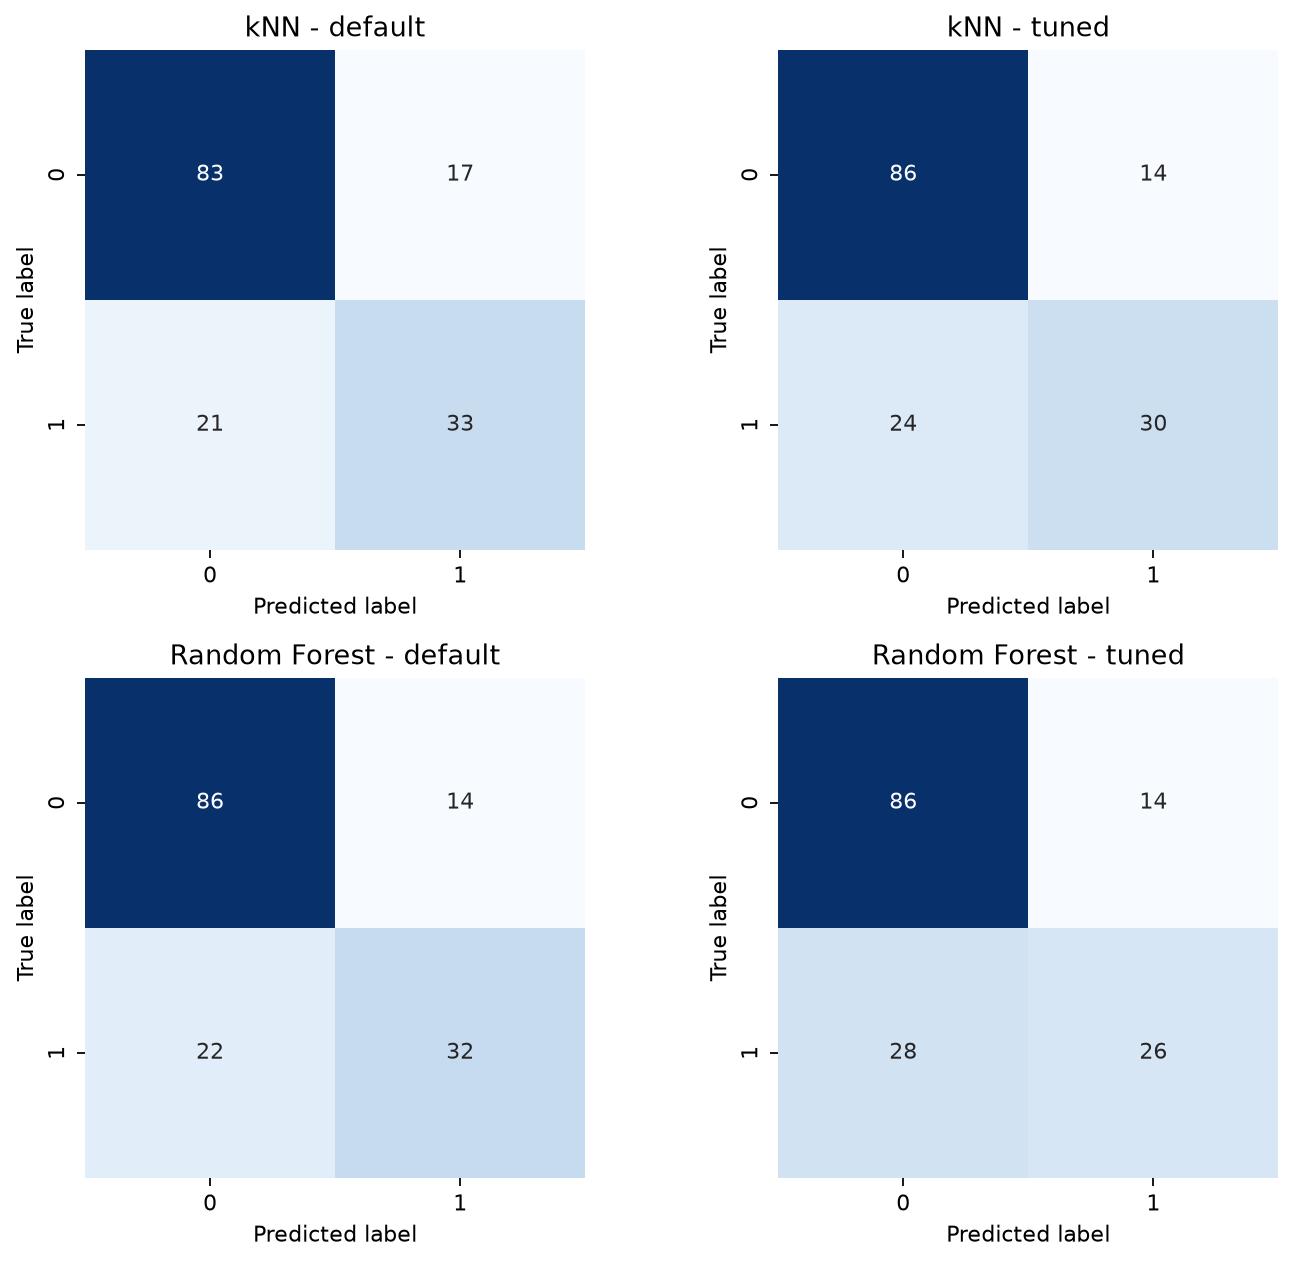

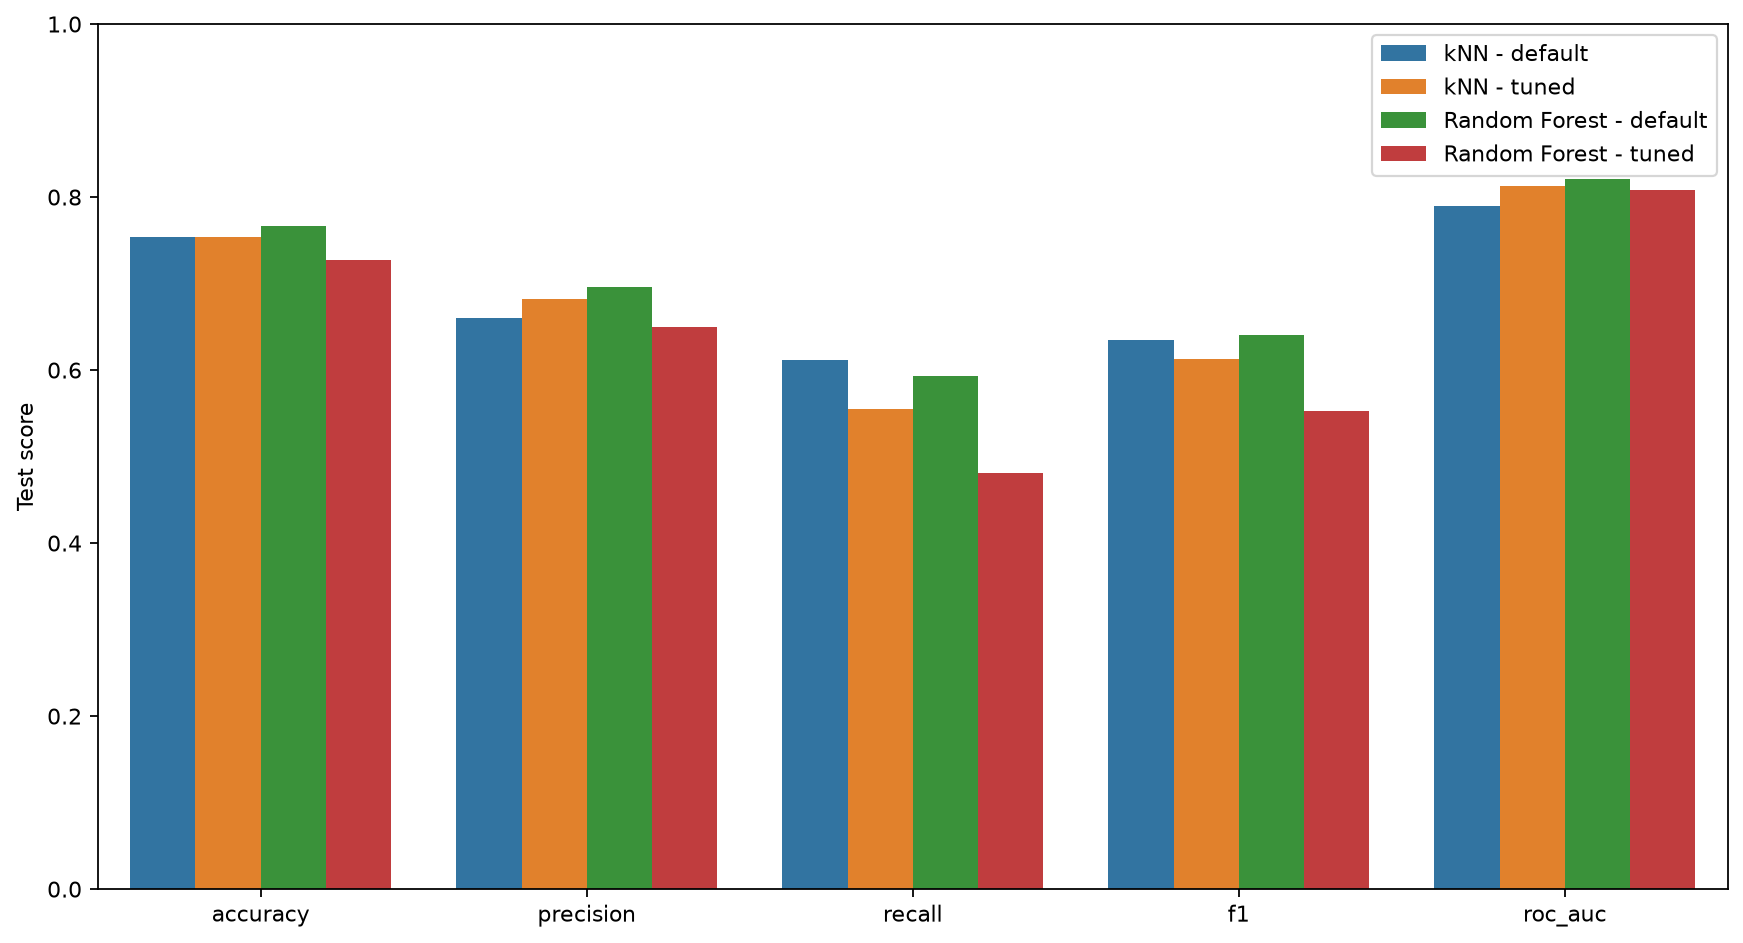

# 糖尿病クラス分類：kNN と Random Forest の比較

## 1. 目的

`diabetes.csv` を用いて糖尿病の有無（`Outcome`）を予測する二値分類モデルを構築し、
k 近傍法（kNN）と Random Forest について、デフォルト設定と
ハイパーパラメータチューニング後の性能を比較した。

## 2. データと前処理

- 全データ数: 768 件
- 学習データ: 614 件（80%）
- テストデータ: 154 件（20%）
- 陽性率: 34.9%
- 分割方法: `random_state=42` の層化分割
- 0 を欠損値として扱った列と件数: `{"Glucose": 5, "BloodPressure": 35, "SkinThickness": 227, "Insulin": 374, "BMI": 11}`
- 欠損値は、学習データ内で算出した中央値により補完
- kNN のみ各特徴量を標準化

前処理はモデルと同じ Pipeline 内で実行し、交差検証時のデータ漏洩を防いだ。

## 3. ハイパーパラメータ探索

5 分割 Stratified K-Fold 交差検証を用い、ROC-AUC が最大になる組み合わせを
GridSearchCV で選択した。最良パラメータは以下の通り。

- **kNN**: `{"n_neighbors": 21, "p": 2, "weights": "distance"}`（最良 CV ROC-AUC: 0.834）
- **Random Forest**: `{"max_depth": 4, "max_features": "log2", "min_samples_leaf": 1, "min_samples_split": 5, "n_estimators": 300}`（最良 CV ROC-AUC: 0.841）

探索範囲は、kNN が近傍数・距離による重み・距離尺度、Random Forest が
木の数・木の深さ・分割に必要なサンプル数・葉に必要なサンプル数・
分割時に使用する特徴量数とした。

## 4. テストデータでの結果

| model         | setting   |   accuracy |   precision |   recall |    f1 |   roc_auc |
|:--------------|:----------|-----------:|------------:|---------:|------:|----------:|
| kNN           | default   |      0.753 |       0.66  |    0.611 | 0.635 |     0.79  |
| kNN           | tuned     |      0.753 |       0.682 |    0.556 | 0.612 |     0.812 |
| Random Forest | default   |      0.766 |       0.696 |    0.593 | 0.64  |     0.821 |
| Random Forest | tuned     |      0.727 |       0.65  |    0.481 | 0.553 |     0.809 |

`accuracy` は全予測の正解率、`precision` は陽性予測の信頼性、
`recall` は実際の糖尿病患者を検出できた割合、`f1` は precision と recall の調和平均、
`roc_auc` は判定閾値に依存しない識別性能を表す。

チューニング前後の差分は以下の通り（正の値が改善）。

- **kNN**（tuned − default）: accuracy +0.000、precision +0.022、recall -0.056、f1 -0.022、roc_auc +0.023
- **Random Forest**（tuned − default）: accuracy -0.039、precision -0.046、recall -0.111、f1 -0.087、roc_auc -0.012

各指標の最高値は、accuracy: Random Forest default（0.766）、precision: Random Forest default（0.696）、recall: kNN default（0.611）、f1: Random Forest default（0.640）、roc_auc: Random Forest default（0.821） だった。

## 5. 考察

kNN はチューニング後も accuracy は同じだったが、ROC-AUC と precision が向上し、
recall と F1 は低下した。Random Forest はチューニング後に全テスト指標が低下した。
これは、ハイパーパラメータを学習データ内の交差検証 ROC-AUC で選んでおり、
未知のテストデータでの改善が保証されるわけではないためである。今回の分割では、
総合的にはデフォルトの Random Forest が最も安定していた。

医療スクリーニングでは偽陰性を減らすことが重要なため、accuracy だけでなく
recall も重視する必要がある。その観点では、今回最も recall が高かった
デフォルト kNN も候補になる。一方、ROC-AUC を重視する場合は
デフォルト Random Forest が最良だった。

今回のテスト結果は単一のホールドアウト分割に対する値であり、
データ分割によるばらつきがある。また、本分析は学習課題用であり、
臨床診断へ直接利用できる性能検証を行ったものではない。

## 6. 再現方法

```bash
uv sync
uv run python main.py
```

数値結果は `results/metrics.csv`、混同行列は
`results/confusion_matrices.png`、指標比較図は `results/metric_comparison.png`
に保存される。


In [32]:
from IPython.display import Image, Markdown, display

display(Image(filename=str(OUTPUT_DIR / "confusion_matrices.png")))
display(Image(filename=str(OUTPUT_DIR / "metric_comparison.png")))
display(Markdown(Path("REPORT.md").read_text(encoding="utf-8")))